## Dependencies & Library Imports

### Overview & Methodology
This cell imports all essential libraries required across the entire EEG preprocessing, interpolation, filtering, and visualization pipeline:
* **Data Manipulation:** `pandas` and `numpy` for tabular data structures and numerical operations.
* **Signal Processing:** `scipy.signal` (`butter`, `filtfilt`, `iirnotch`, `welch`) for zero-phase digital filtering and spectral analysis, alongside `scipy.interpolate` (`pchip_interpolate`) for monotonic signal resampling.
* **Visualization:** `matplotlib.pyplot` for plotting time-series signals and Power Spectral Density (PSD) charts.
* **Preprocessing & Scaling:** `sklearn.preprocessing.StandardScaler` for channel-wise Z-score normalization.

In [1]:
import glob # File path matching and directory navigation
import re # Regular expressions for string pattern matching and ID extraction
import pandas as pd # Data structures and tabular data manipulation
import numpy as np # Numerical computing and array operations
from scipy.interpolate import pchip_interpolate # Monotonic cubic interpolation for uniform resampling
import matplotlib.pyplot as plt # Plotting and data visualization
from scipy.signal import (
welch, # Spectral density estimation using Welch's method
butter, # Butterworth IIR filter design
filtfilt, # Forward-backward zero-phase digital filtering
iirnotch # Second-order IIR notch filter design
)
from sklearn.preprocessing import StandardScaler # Z-score standardization (zero mean, unit variance)

## Step 1: Load & Organize EEG Data

### Overview & Methodology
This initial step ingests raw, scattered EEG trial CSV files and unifies them into a single structured DataFrame ready for signal processing:
* **Label Association:** Reads `labels.csv` and maps ground-truth class targets (`LEFT` / `RIGHT`) to each trial based on the trial ID extracted from the file name.
* **Trial Isolation:** Injects a unique `trial_id` column to every trial segment, guaranteeing that subsequent filtering and epoching steps run independently per trial without cross-trial data contamination.
* **Dataset Aggregation:** Concatenates individual trial DataFrames into a comprehensive dataset (`full_eeg_df`).

In [2]:
# Helper function to extract the numerical trial ID from a file path using Regex
def get_trial_number(filepath):
    # Search for all sequence of digits in the file path
    numbers = re.findall(r"\d+", filepath)
    # Return the last matched number (representing trial ID) or -1 if none found
    return int(numbers[-1]) if numbers else -1


# 1. Load the labels file containing ground-truth targets (LEFT / RIGHT)
labels_df = pd.read_csv(r"C:\Users\USER\Downloads\labels.csv")

# 2. Define directory path and fetch all raw EEG trial CSV files
folder_path = (
    r"C:\Users\USER\Downloads\MI-20260819T190159Z-1-001\MI\MI CSV\*.csv"
)
file_paths = glob.glob(folder_path)

# Initialize container for individual trial DataFrames
all_dfs = []

# Iterate through every file path to load and attach relevant metadata
for path in file_paths:
    # Extract trial number from filename
    file_num = get_trial_number(path)
    # Convert trial number to 0-based index for labels lookup
    label_idx = file_num - 1
    
    # Validate index boundary against the labels Dataframe
    if 0 <= label_idx < len(labels_df):
        # Load raw EEG trial CSV
        df_trial = pd.read_csv(path)

        # Inject unique trial identifier to prevent inter-trial data bleeding
        df_trial["trial_id"] = file_num

        # Assign class label (LEFT or RIGHT) corresponding to this trial
        df_trial["label"] = labels_df.iloc[label_idx]["label"]

        # Append individual trial to collection list
        all_dfs.append(df_trial)

# 3. Concatenate all trial DataFrames into a single unified Dataset
full_eeg_df = pd.concat(all_dfs, ignore_index=True)

# Display dataset dimensions and initial head rows to verify integrity
print("Unified Dataset Shape:", full_eeg_df.shape)
print(full_eeg_df.head())

Unified Dataset Shape: (5400000, 7)
           Time            FZ            C3            CZ            C4  \
0  88451.201876  324761.37500  321002.62500  335287.28125  321417.90625   
1  88451.221777  325001.18750  321223.09375  335409.56250  320937.09375   
2  88451.221788  324896.75000  321045.53125  334954.40625  320233.56250   
3  88451.229576  324627.28125  320756.12500  334589.43750  320262.25000   
4  88451.229588  324538.31250  320729.21875  334804.56250  321010.50000   

   trial_id label  
0         1  Left  
1         1  Left  
2         1  Left  
3         1  Left  
4         1  Left  


## Step 1.1: Verify Dataset Schema & Column Data Types

### Overview & Methodology
Checking the DataFrame data types (`dtypes`) ensures that numerical columns (timestamps and sensor channels) are formatted correctly for mathematical computations:
* **Feature Data Types:** Confirms that target channels (`FZ`, `C3`, `CZ`, `C4`) and `Time` are `float64` or `int64` to prevent type-casting errors during digital filtering and interpolation.
* **Metadata Identification:** Validates that `trial_id` and categorical target `label` maintain appropriate integer and object/string formats respectively.

In [3]:
# Inspect the data types of all columns in the unified dataset
full_eeg_df.dtypes

Time        float64
FZ          float64
C3          float64
CZ          float64
C4          float64
trial_id      int64
label        object
dtype: object

## Step 1.2: Sort Dataset by Trial ID & Timestamp

### Overview & Methodology
Ensuring proper chronological order across all trials is critical prior to executing signal processing algorithms:
* **Sequential Integrity:** Sorts the DataFrame hierarchically first by `trial_id` and then by `Time` to guarantee that time-series samples within each trial flow strictly forward.
* **Filter Preparedness:** Prevents sample inversion and time-step discontinuities, ensuring that phase response and digital filtering functions (`filtfilt`) process contiguous time samples correctly.

In [4]:
# Sort the DataFrame hierarchically: by trial_id first, then chronologically by Time within each trial
full_eeg_df = full_eeg_df.sort_values(by=["trial_id", "Time"])

## Step 1.3: Zero-Base Trial Timestamps

### Overview & Methodology
Aligning the temporal axis for every trial independently standardizes the starting point across the entire dataset:
* **Time Alignment:** Subtracts the initial timestamp of each trial from all subsequent time samples within that specific group (`lambda x: x - x.iloc[0]`).
* **Epoch Synchronization:** Guarantees that every trial starts precisely at $t = 0.0\text{ s}$, facilitating clean windowing, time-locking, and epoch extraction in downstream processing steps.

In [5]:
# Reset the Time axis to start at 0.0 seconds independently for each trial
full_eeg_df["Time"] = full_eeg_df.groupby("trial_id")["Time"].transform(
    lambda x: x - x.iloc[0]
)
full_eeg_df

,Time,FZ,C3,CZ,C4,trial_id,label
0,0.000000,324761.37500,321002.62500,335287.28125,321417.90625,1,Left
1,0.019901,325001.18750,321223.09375,335409.56250,320937.09375,1,Left
2,0.019911,324896.75000,321045.53125,334954.40625,320233.56250,1,Left
3,0.027700,324627.28125,320756.12500,334589.43750,320262.25000,1,Left
4,0.027712,324538.31250,320729.21875,334804.56250,321010.50000,1,Left
...,...,...,...,...,...,...,...
3229995,9.970911,305151.65625,312158.21875,318423.25000,299972.59375,2160,Right
3229996,9.980236,304871.00000,312427.59375,318254.62500,299410.84375,2160,Right
3229997,9.980280,304966.21875,312542.50000,318363.87500,299443.65625,2160,Right
3229998,9.987246,305320.65625,312367.78125,318645.50000,300074.68750,2160,Right


## Step 2: Time-Delta Analysis & Sampling Rate Inspection

### Overview & Methodology
This step evaluates the continuity and consistency of time intervals ($\Delta t$) between consecutive samples within an individual trial:
* **Sampling Stability Assessment:** Computes the average sample interval (`mean()`) to estimate the effective sampling frequency ($f_s = \frac{1}{\Delta t}$).
* **Missing Sample & Gap Detection:** Identifies potential hardware packet losses, irregular sampling jitter, or timestamps drops by examining the maximum recorded interval (`max()`).
* **Resampling Justification:** A maximum time delta significantly exceeding the mean indicates missing observations, justifying downstream non-uniform interpolation (PCHIP).

In [6]:
# Isolate time samples for a representative single trial (Trial 1)
trial_sample = full_eeg_df[full_eeg_df["trial_id"] == 1]

# Compute consecutive time differences (dt) and drop the initial NaN value
time_diffs = trial_sample["Time"].diff().dropna()

# Output average time delta and peak gap duration
print("Expected Mean Time Delta (dt):", time_diffs.mean())
print("Maximum Recorded Gap inside Trial:", time_diffs.max())

# Note: A max dt significantly greater than the mean indicates data loss/sampling gaps

Expected Mean Time Delta (dt): 0.003999618287319599
Maximum Recorded Gap inside Trial: 0.15393899999617133


## Step 2.1: Dataset-Wide Effective Sampling Frequency Estimation

### Overview & Methodology
This step computes the exact global effective sampling rate ($f_s$) across every trial in the dataset:
* **Per-Trial Sampling Rate Calculation:** Measures total trial duration ($\Delta T = T_{\text{end}} - T_{\text{start}}$) and calculates the individual frequency ($f_{\text{trial}} = \frac{N}{\Delta T}$) per trial.
* **Global Frequency Consensus:** Aggregates individual sampling rates across all trials and applies rounded averaging (`np.round(np.mean())`) to establish a single, robust target frequency ($f_s = 250\text{ Hz}$).
* **Pipeline Synchronization:** Establishes the authoritative sampling rate required to define Nyquist frequencies for subsequent digital filters and PCHIP resampling grids.

In [7]:
# Container to store calculated sampling frequency for each trial
fs_list = []

# Calculate duration and effective sampling rate for every trial independently
for trial_id, group in full_eeg_df.groupby("trial_id"):
    duration = group["Time"].iloc[-1] - group["Time"].iloc[0]
    if duration > 0:
        trial_fs = len(group) / duration
        fs_list.append(trial_fs)

# Compute rounded dataset-wide average sampling frequency
overall_real_fs = int(np.round(np.mean(fs_list)))

# Display the global sampling frequency (Hz)
print(
    f"Dataset-wide Effective Target Sampling Frequency (fs): {overall_real_fs} Hz"
)

Dataset-wide Effective Target Sampling Frequency (fs): 250 Hz


## Step 2.2: Gap Diagnostic & Sampling Anomaly Inspection

### Overview & Methodology
This diagnostic check inspects the sample-to-sample timing stability across initial trials to detect packet loss or non-uniform sampling:
* **Median Delta ($\text{dt}_{\text{med}}$) Estimation:** Computes the robust median time step ($\Delta t$) per trial, minimizing susceptibility to single-sample timestamp anomalies.
* **Gap Anomaly Detection:** Identifies timing delays exceeding $1.5 \times \text{dt}_{\text{med}}$ to quantify missing sample periods relative to total trial duration.
* **Resampling Strategy Validation:** Evaluates whether timing irregularities are minor enough to be restored via monotonic cubic spline interpolation (PCHIP), or severe enough to justify dropping heavily corrupted trials.

In [8]:
# Inspect gap metrics for the first 5 trials to check sampling stability
for trial_id, group in list(full_eeg_df.groupby("trial_id"))[:5]:
    # Extract chronologically sorted time arrays
    time_vals = group["Time"].sort_values().values

    # Calculate time differences between adjacent samples
    dt = np.diff(time_vals)

    # Compute robust median sample interval
    med_dt = np.median(dt)

    # Calculate total duration lost to anomalous gaps (> 1.5 * median dt)
    gaps = np.sum(dt[dt > 1.5 * med_dt] - med_dt)

    # Calculate total duration span of the trial
    span = time_vals[-1] - time_vals[0]

    # Display diagnostic output per trial
    print(
        f"Trial: {trial_id} | Median dt: {med_dt:.6f}s | Total Span: {span:.3f}s | Gap Ratio: {gaps/span if span > 0 else 0:.4f}"
    )

Trial: 1 | Median dt: 0.002403s | Total Span: 9.995s | Gap Ratio: 0.6246
Trial: 2 | Median dt: 0.002493s | Total Span: 9.994s | Gap Ratio: 0.5253
Trial: 3 | Median dt: 0.002473s | Total Span: 9.992s | Gap Ratio: 0.5576
Trial: 4 | Median dt: 0.002413s | Total Span: 10.030s | Gap Ratio: 0.6199
Trial: 5 | Median dt: 0.002476s | Total Span: 10.003s | Gap Ratio: 0.5572


## Step 3: Time Discontinuity Repair & PCHIP Resampling Pipeline

### Overview & Methodology
This step implements a trial-level Quality Assurance (QA) and resampling pipeline to handle missing samples and non-uniform sampling rate jitter:
* **True Gap Thresholding:** Detects significant temporal jumps exceeding $50\text{ ms}$ ($\ge 5 \times \Delta t_{\text{target}}$) to separate minor sampling clock jitter from actual packet loss.
* **Loss-Based Trial Rejection:** Evaluates total trial corruption by calculating the maximum between explicit `NaN` values and missing time gaps. If total signal loss exceeds $10\%$ (`max_nan_ratio=0.10`), the trial is rejected to prevent spectral distortion.
* **PCHIP Resampling:** For accepted trials, Piecewise Cubic Hermite Interpolating Polynomial (`pchip_interpolate`) rebuilds a uniform time grid at exactly $250\text{ Hz}$ while preserving signal monotonicity and preventing artificial overshoots.

In [9]:
def fix_time_discontinuity_clean(
    df_trial, max_nan_ratio=0.10, target_fs=250.0
):
    # Create an independent copy sorted chronologically by time
    df = df_trial.copy().sort_values("Time")

    trial_id = df["trial_id"].iloc[0]
    label = df["label"].iloc[0]

    # Isolate EEG channel columns excluding metadata
    eeg_cols = [
        col for col in df.columns if col not in ["Time", "trial_id", "label"]
    ]

    time_vals = df["Time"].values
    dt_series = np.diff(time_vals)

    # Reference time step for 250 Hz target frequency (dt = 0.004s)
    target_dt = 1.0 / target_fs
    total_duration = time_vals[-1] - time_vals[0]

    # 1. Detect true gaps: jumps exceeding 50ms (or 5x target_dt)
    gap_threshold = max(0.050, 5.0 * target_dt)
    large_gaps = dt_series[dt_series > gap_threshold]

    # Compute duration of lost time and its ratio relative to total trial length
    missing_time = (
        np.sum(large_gaps - target_dt) if len(large_gaps) > 0 else 0
    )
    time_gap_ratio = missing_time / total_duration if total_duration > 0 else 0

    # Calculate explicit NaN value ratio across EEG channels
    explicit_nan_ratio = df[eeg_cols].isna().sum().max() / len(df)

    # Combined total signal corruption ratio
    total_nan_ratio = max(time_gap_ratio, explicit_nan_ratio)

    # 2. Rejection decision if corruption ratio exceeds 10% tolerance threshold
    if total_nan_ratio > max_nan_ratio:
        return None, total_nan_ratio

    # 3. Monotonic Cubic Spline Interpolation (PCHIP) on fixed 250 Hz grid
    expected_samples = int(np.round(total_duration * target_fs)) + 1
    regular_time = np.linspace(time_vals[0], time_vals[-1], expected_samples)

    # Resample each EEG channel onto the uniform timeline
    resample_dict = {"Time": regular_time}
    for col in eeg_cols:
        resample_dict[col] = pchip_interpolate(
            time_vals, df[col].values, regular_time
        )

    # Reconstruct cleaned trial DataFrame
    df_clean_trial = pd.DataFrame(resample_dict)
    df_clean_trial["trial_id"] = trial_id
    df_clean_trial["label"] = label

    return df_clean_trial, total_nan_ratio


# --- Pipeline Execution & Summary Aggregation ---
processed_trials = []
rejected_trials = []

# Process each trial independently through the QA & Resampling pipeline
for trial_id, group in full_eeg_df.groupby("trial_id"):
    cleaned_trial, nan_ratio = fix_time_discontinuity_clean(
        group, max_nan_ratio=0.10, target_fs=250.0
    )

    if cleaned_trial is None:
        rejected_trials.append({"trial_id": trial_id, "nan_ratio": nan_ratio})
    else:
        processed_trials.append(cleaned_trial)

# Consolidate accepted trials into single cleaned DataFrame
if len(processed_trials) > 0:
    df_clean = pd.concat(processed_trials, ignore_index=True)
    total_trials = full_eeg_df["trial_id"].nunique()
    num_rejected = len(rejected_trials)
    rejection_rate = (num_rejected / total_trials) * 100

    # Print Quality Control Metrics Summary
    print("=== Artifact & Continuity Report ===")
    print(f"Total Trials Processed : {total_trials}")
    print(f"Accepted Trials        : {len(processed_trials)}")
    print(f"Rejected Trials        : {num_rejected}")
    print(f"Rejection Rate         : {rejection_rate:.2f}%")
else:
    print("Warning: All trials exceeded noise thresholds. Check raw timestamps.")

=== Artifact & Continuity Report ===
Total Trials Processed : 2160
Accepted Trials        : 1790
Rejected Trials        : 370
Rejection Rate         : 17.13%


## Step 3.1: Post-Cleaning Data Integrity & Quality Sanity Check

### Overview & Methodology
This evaluation verifies dataset health and class consistency following the artifact rejection and PCHIP resampling stage:
* **Class Balance Verification:** Assesses the distribution of target labels (`LEFT` vs `RIGHT`) across accepted trials to ensure rejection rules did not introduce severe class imbalance.
* **Trial Length & Sampling Uniformity:** Inspects summary statistics of per-trial sample counts to confirm that every trial has been resampled onto an identical temporal length.
* **Signal Integrity & Flatline Detection:** Validates zero remaining `NaN` values and flags potential hardware failure (flatline signals where standard deviation $\sigma = 0$) across target channels (`FZ`, `C3`, `CZ`, `C4`).

In [10]:
# Target motor imagery EEG channels
CHANNELS = ["FZ", "C3", "CZ", "C4"]

# --- 1. Class Balance Verification ---
trial_labels = df_clean.groupby("trial_id")["label"].first()
print("=== 1. Cleaned Class Balance ===")
print(trial_labels.value_counts())
print(f"\nPercentages:\n{trial_labels.value_counts(normalize=True) * 100}")

# --- 2. Trial Lengths & Sampling Consistency Summary ---
trial_lengths = df_clean.groupby("trial_id")["Time"].count()
print("\n=== 2. Cleaned Trial Samples Summary ===")
print(trial_lengths.describe())

# --- 3. Missing Values & Flat Channel Inspection ---
print("\n=== 3. Missing Values & Flat Channels ===")
print("NaNs per column:\n", df_clean[CHANNELS].isna().sum())

# Detect invariant channels across individual trials (zero variance / std == 0)
flat_channels = df_clean.groupby("trial_id")[CHANNELS].std() == 0
print(
    "\nNumber of flat channel occurrences across all trials:",
    flat_channels.sum().sum(),
)

=== 1. Cleaned Class Balance ===
label
Right    901
Left     889
Name: count, dtype: int64

Percentages:
label
Right    50.335196
Left     49.664804
Name: proportion, dtype: float64

=== 2. Cleaned Trial Samples Summary ===
count    1790.000000
mean     2496.461453
std        14.655363
min      2323.000000
25%      2495.000000
50%      2497.000000
75%      2499.000000
max      2623.000000
Name: Time, dtype: float64

=== 3. Missing Values & Flat Channels ===
NaNs per column:
 FZ    0
C3    0
CZ    0
C4    0
dtype: int64

Number of flat channel occurrences across all trials: 0


## Step 3.2: Exploratory Signal & Spectral Analysis (Time Domain & Welch PSD)

### Overview & Methodology
This exploratory visualization assesses both time-domain waveforms and frequency-domain characteristics of cleaned EEG signals across contralateral motor cortex channels (`C3` and `C4`):
* **Sampling Rate Estimation:** Dynamically extracts the effective sampling rate ($f_s = \frac{1}{\Delta t}$) from the resampled timeline to parameterize spectral calculations accurately.
* **Time-Domain Inspection:** Plots individual raw signal amplitudes across representative `LEFT` and `RIGHT` motor imagery trials to visually verify signal continuity and amplitude ranges.
* **Welch Power Spectral Density (PSD):** Computes class-averaged power spectral densities ($0\text{–}100\text{ Hz}$) using Welch's periodogram method (`nperseg = 2 * fs`). This reveals power peaks in low-frequency bandpass ranges (Mu/Beta rhythms around $8\text{–}30\text{ Hz}$) and highlights high-frequency noise or $50\text{/}\text{60 Hz}$ powerline interference prior to digital filtering.

Estimated Sampling Rate (fs): 250 Hz


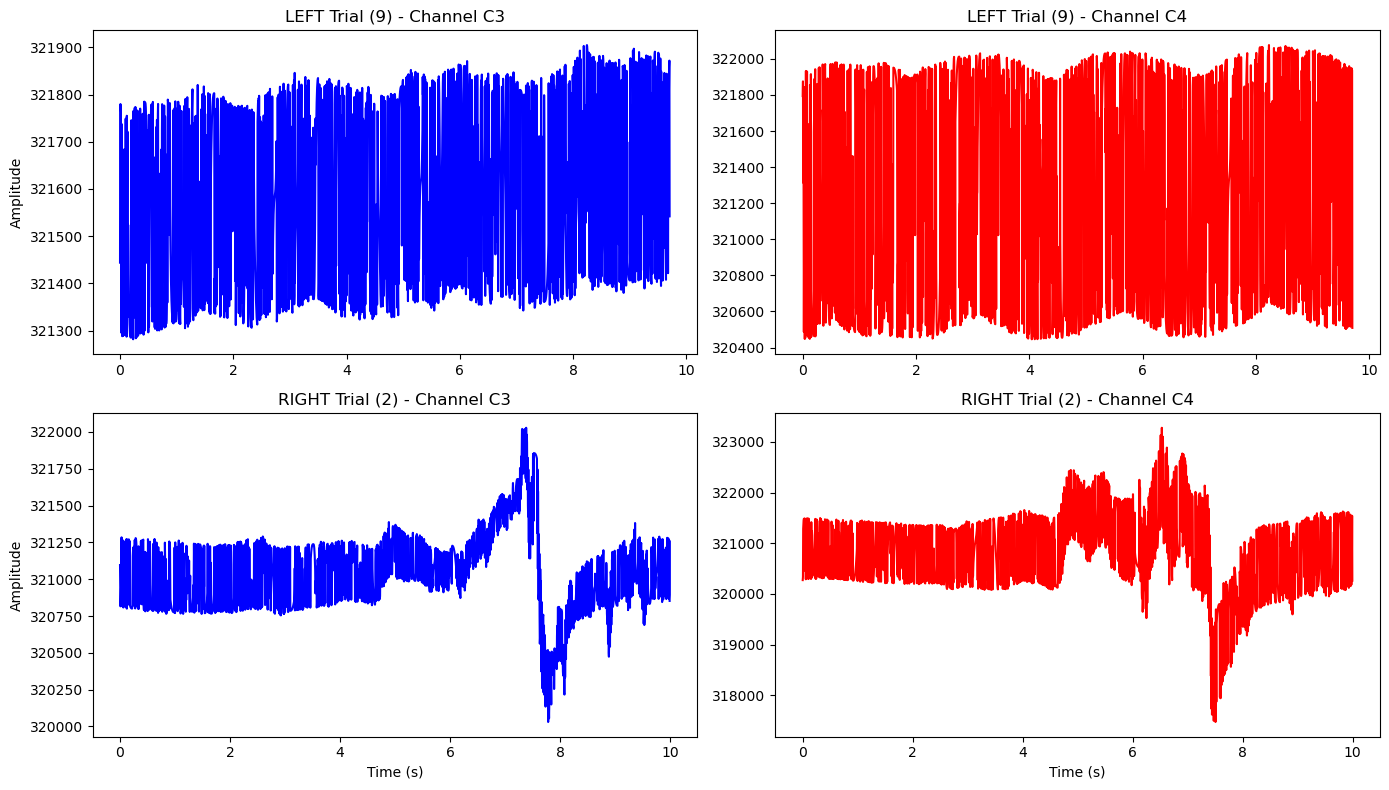

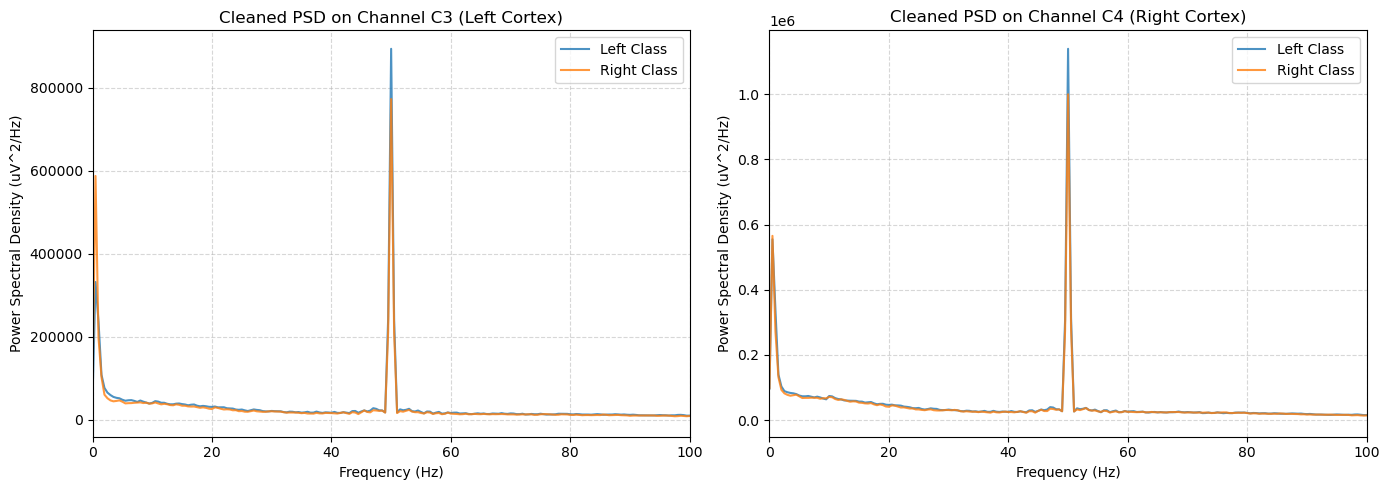

In [11]:
# Target motor imagery EEG channels
CHANNELS = ["FZ", "C3", "CZ", "C4"]

# --- Dynamically estimate actual sampling rate (fs) from df_clean ---
first_trial = df_clean[df_clean["trial_id"] == df_clean["trial_id"].iloc[0]]
dt = np.median(np.diff(first_trial["Time"].values))
estimated_fs = int(np.round(1.0 / dt))
print(f"Estimated Sampling Rate (fs): {estimated_fs} Hz")

# --- 1. Time-Domain Visualization (Channels C3 & C4) ---
sample_left = df_clean[df_clean["label"] == "Left"]["trial_id"].unique()[0]
sample_right = df_clean[df_clean["label"] == "Right"]["trial_id"].unique()[0]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False)

# Left Class Sample Plots
df_l = df_clean[df_clean["trial_id"] == sample_left]
axes[0, 0].plot(df_l["Time"], df_l["C3"], color="b", label="C3 (Left Motor)")
axes[0, 0].set_title(f"LEFT Trial ({sample_left}) - Channel C3")
axes[0, 0].set_ylabel("Amplitude")

axes[0, 1].plot(df_l["Time"], df_l["C4"], color="r", label="C4 (Right Motor)")
axes[0, 1].set_title(f"LEFT Trial ({sample_left}) - Channel C4")

# Right Class Sample Plots
df_r = df_clean[df_clean["trial_id"] == sample_right]
axes[1, 0].plot(df_r["Time"], df_r["C3"], color="b")
axes[1, 0].set_title(f"RIGHT Trial ({sample_right}) - Channel C3")
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("Amplitude")

axes[1, 1].plot(df_r["Time"], df_r["C4"], color="r")
axes[1, 1].set_title(f"RIGHT Trial ({sample_right}) - Channel C4")
axes[1, 1].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()


# --- 2. Spectral Analysis: Class-Averaged Power Spectral Density (PSD) ---
def compute_psd_for_class(df, label_name, channel, fs):
    psds = []
    trials = df[df["label"] == label_name]["trial_id"].unique()
    for t in trials:
        signal = df[df["trial_id"] == t][channel].values
        # Apply Welch periodogram using a 2-second segment window
        nper = min(len(signal), fs * 2) 
        freqs, psd = welch(signal, fs=fs, nperseg=nper)
        psds.append(psd)
    return freqs, np.mean(psds, axis=0)


plt.figure(figsize=(14, 5))

# Channel C3 (Left Hemisphere) PSD
plt.subplot(1, 2, 1)
f_l, psd_l_c3 = compute_psd_for_class(df_clean, "Left", "C3", fs=estimated_fs)
f_r, psd_r_c3 = compute_psd_for_class(df_clean, "Right", "C3", fs=estimated_fs)
plt.plot(f_l, psd_l_c3, label="Left Class", alpha=0.8)
plt.plot(f_r, psd_r_c3, label="Right Class", alpha=0.8)
plt.xlim(0, 100)  # Inspect frequency band up to 100 Hz
plt.title("Cleaned PSD on Channel C3 (Left Cortex)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (uV^2/Hz)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

# Channel C4 (Right Hemisphere) PSD
plt.subplot(1, 2, 2)
f_l, psd_l_c4 = compute_psd_for_class(df_clean, "Left", "C4", fs=estimated_fs)
f_r, psd_r_c4 = compute_psd_for_class(df_clean, "Right", "C4", fs=estimated_fs)
plt.plot(f_l, psd_l_c4, label="Left Class", alpha=0.8)
plt.plot(f_r, psd_r_c4, label="Right Class", alpha=0.8)
plt.xlim(0, 100)
plt.title("Cleaned PSD on Channel C4 (Right Cortex)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (uV^2/Hz)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## Step 4: Digital Signal Filtering Pipeline (Notch & Bandpass Filtering)

### Overview & Methodology
This step applies sequential zero-phase digital filtering across every accepted trial independently:
* **Powerline Interference Suppression (50 Hz Notch Filter):** Designs an Infinite Impulse Response (IIR) Notch filter (`iirnotch`, $Q = 30$) centered at $50\text{ Hz}$ to eliminate AC mains powerline hum and electrical grid noise.
* **Motor Imagery Frequency Band Extraction (0.5–40 Hz Bandpass Filter):** Implements a 4th-order Butterworth Bandpass filter (`butter`, $N = 4$) to preserve relevant physiological EEG bands (Delta, Theta, Alpha/Mu, and Beta rhythms) while suppressing low-frequency baseline wander ($< 0.5\text{ Hz}$) and high-frequency muscular (EMG) artifacts ($> 40\text{ Hz}$).
* **Per-Trial Boundary Protection (`filtfilt`):** Runs zero-phase forward-backward filtering (`filtfilt`) grouped by `trial_id` to eliminate phase distortion while preventing transient edge artifacts from leaking between independent trials.

In [12]:
# Target motor imagery EEG channels
CHANNELS = ["FZ", "C3", "CZ", "C4"]

# 1. Target sampling rate fixed across the dataset post-resampling
TARGET_FS = 250


# 2. Complete digital filtering function applied per trial
def apply_pipeline_filters(df, channels, fs=250):
    df_filtered = df.copy()

    # Step A: Design 50 Hz IIR Notch filter (Q-factor = 30)
    b_notch, a_notch = iirnotch(w0=50.0, Q=30.0, fs=fs)

    # Step B: Design 4th-order Butterworth Bandpass filter (0.5 - 40 Hz)
    lowcut, highcut = 0.5, 40.0
    nyq = 0.5 * fs
    b_band, a_band = butter(
        N=4, Wn=[lowcut / nyq, highcut / nyq], btype="band"
    )

    processed_groups = []
    
    # Process each trial independently to prevent inter-trial filter bleeding
    for trial_id, group in df_filtered.groupby("trial_id"):
        group_clean = group.copy()
        for col in channels:
            sig = group[col].values
            
            # Apply notch filter followed by bandpass filter using zero-phase filtfilt
            sig_notch = filtfilt(b_notch, a_notch, sig)
            sig_band = filtfilt(b_band, a_band, sig_notch)

            group_clean[col] = sig_band

        processed_groups.append(group_clean)

    return pd.concat(processed_groups, ignore_index=True)

# 3. Execute filtering pipeline across all accepted trials
df_filtered = apply_pipeline_filters(df_clean, CHANNELS, fs=TARGET_FS)
print(
    f"Filtering completed successfully for all trials using fixed fs = {TARGET_FS} Hz!"
)

Filtering completed successfully for all trials using fixed fs = 250 Hz!


## Step 4.1: Post-Filtering Diagnostic & Spectral Verification

### Overview & Methodology
This diagnostic step evaluates the effectiveness of the digital filtering pipeline in both time and frequency domains:
* **Waveform Stabilization:** Verifies that baseline drift and high-amplitude transients have been removed from time-series signals (`C3` and `C4`), leaving smooth, stationary EEG oscillations.
* **Powerline Hum Elimination:** Confirms the successful removal of $50\text{ Hz}$ powerline interference via the notch filter sharp attenuation drop at $50\text{ Hz}$.
* **Passband Bandwidth Validation:** Evaluates the power distribution across the $0\text{–}60\text{ Hz}$ spectrum, confirming that spectral power is strictly constrained within the design bandpass range ($0.5\text{–}40\text{ Hz}$) with steep roll-off above $40\text{ Hz}$.

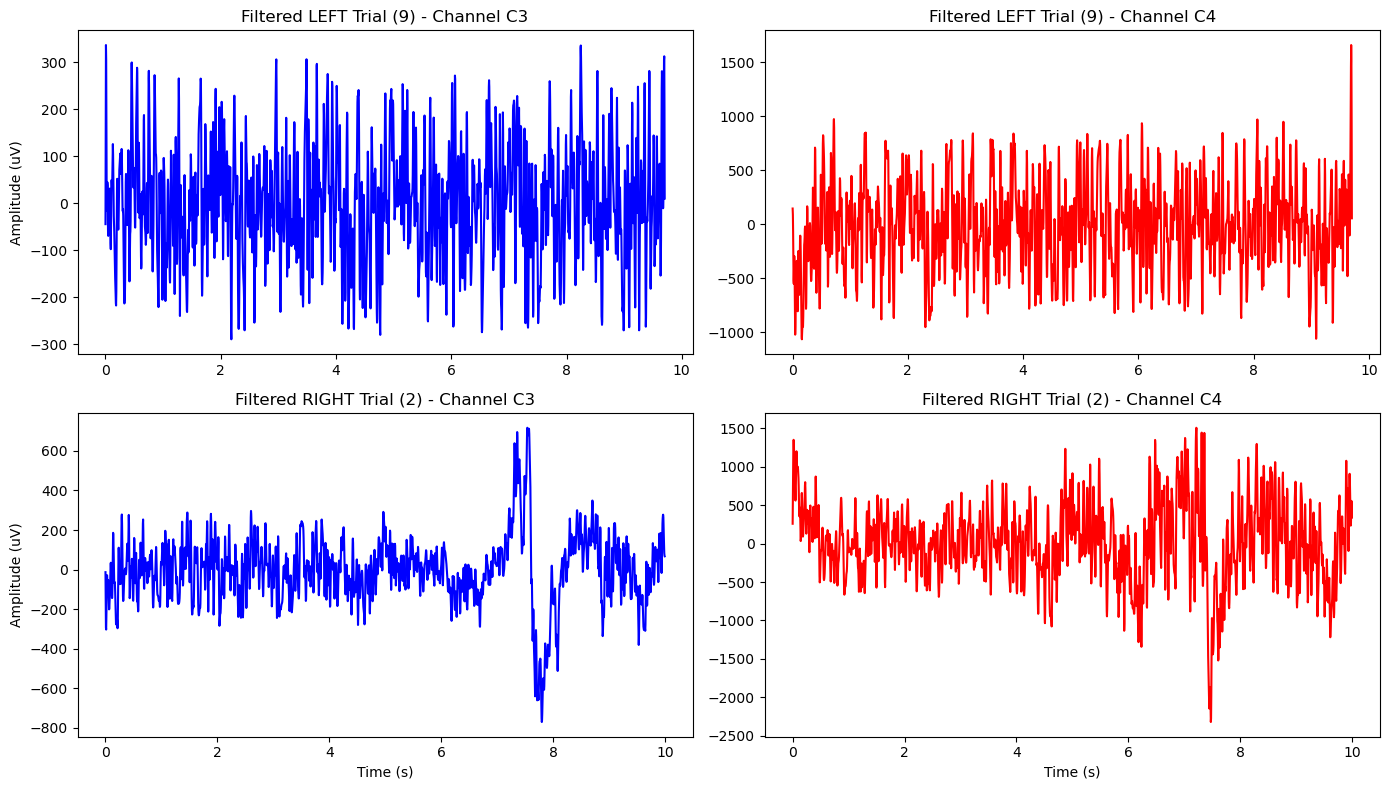

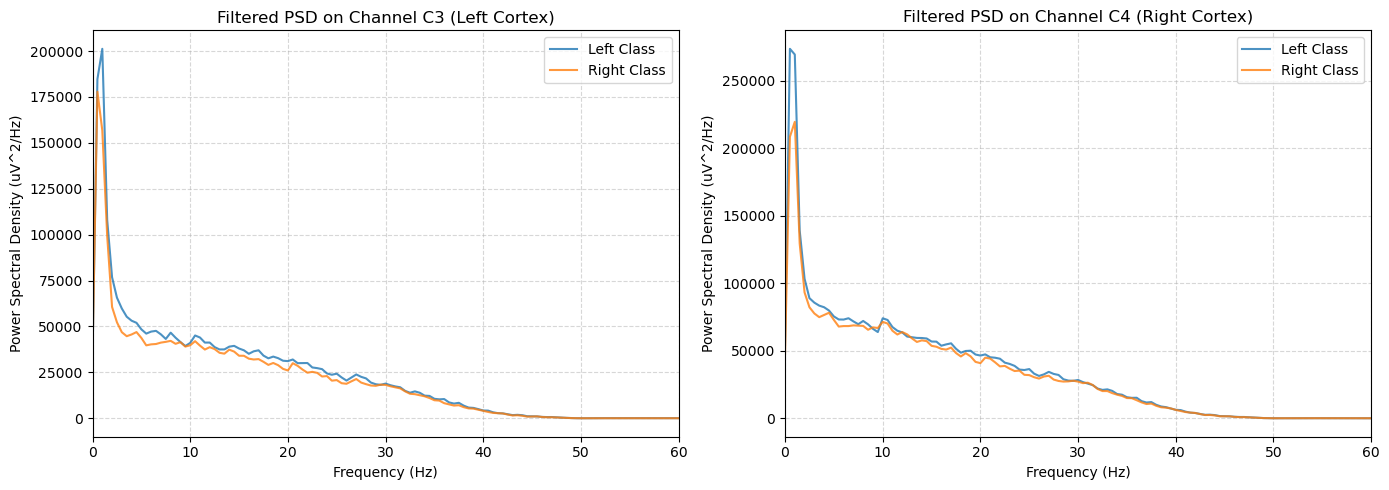

In [13]:
# --- 1. Time-Domain Visualization Post-Filtering ---
sample_left = df_filtered[df_filtered["label"] == "Left"]["trial_id"].unique()[
    0
]
sample_right = df_filtered[df_filtered["label"] == "Right"][
    "trial_id"
].unique()[0]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False)

# Left Class Sample Plots
df_l = df_filtered[df_filtered["trial_id"] == sample_left]
axes[0, 0].plot(df_l["Time"], df_l["C3"], color="b", label="C3 (Left Motor)")
axes[0, 0].set_title(f"Filtered LEFT Trial ({sample_left}) - Channel C3")
axes[0, 0].set_ylabel("Amplitude (uV)")

axes[0, 1].plot(df_l["Time"], df_l["C4"], color="r", label="C4 (Right Motor)")
axes[0, 1].set_title(f"Filtered LEFT Trial ({sample_left}) - Channel C4")

# Right Class Sample Plots
df_r = df_filtered[df_filtered["trial_id"] == sample_right]
axes[1, 0].plot(df_r["Time"], df_r["C3"], color="b")
axes[1, 0].set_title(f"Filtered RIGHT Trial ({sample_right}) - Channel C3")
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("Amplitude (uV)")

axes[1, 1].plot(df_r["Time"], df_r["C4"], color="r")
axes[1, 1].set_title(f"Filtered RIGHT Trial ({sample_right}) - Channel C4")
axes[1, 1].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()


# --- 2. Spectral Analysis: Post-Filtering Power Spectral Density (PSD) ---
def compute_psd_for_class(df, label_name, channel, fs):
    psds = []
    trials = df[df["label"] == label_name]["trial_id"].unique()
    for t in trials:
        signal = df[df["trial_id"] == t][channel].values
        nper = min(len(signal), fs * 2)
        freqs, psd = welch(signal, fs=fs, nperseg=nper)
        psds.append(psd)
    return freqs, np.mean(psds, axis=0)


plt.figure(figsize=(14, 5))

# Channel C3 (Left Hemisphere) Filtered PSD
plt.subplot(1, 2, 1)
f_l, psd_l_c3 = compute_psd_for_class(
    df_filtered, "Left", "C3", fs=estimated_fs
)
f_r, psd_r_c3 = compute_psd_for_class(
    df_filtered, "Right", "C3", fs=estimated_fs
)
plt.plot(f_l, psd_l_c3, label="Left Class", alpha=0.8)
plt.plot(f_r, psd_r_c3, label="Right Class", alpha=0.8)
plt.xlim(0, 60)  # التركيز على النطاق المغطى من 0 إلى 60 Hz
plt.title("Filtered PSD on Channel C3 (Left Cortex)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (uV^2/Hz)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

# Channel C4 (Right Hemisphere) Filtered PSD
plt.subplot(1, 2, 2)
f_l, psd_l_c4 = compute_psd_for_class(
    df_filtered, "Left", "C4", fs=estimated_fs
)
f_r, psd_r_c4 = compute_psd_for_class(
    df_filtered, "Right", "C4", fs=estimated_fs
)
plt.plot(f_l, psd_l_c4, label="Left Class", alpha=0.8)
plt.plot(f_r, psd_r_c4, label="Right Class", alpha=0.8)
plt.xlim(0, 60)
plt.title("Filtered PSD on Channel C4 (Right Cortex)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (uV^2/Hz)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## Step 5: Post-Processing & Feature Standardization Pipeline

### Overview & Methodology
This comprehensive pipeline executes spatial re-referencing, temporal epoching, outlier rejection, baseline correction, and channel normalization:
* **Common Average Reference (CAR):** Subtracts the spatial mean amplitude across all electrode channels ($\text{CAR}_t = \frac{1}{N}\sum_{i=1}^N V_{i,t}$) at each time point, isolating local motor cortex activity (`C3`/`C4`) from global background noise.
* **Temporal Epoching ($0.5\text{s}\text{--}3.5\text{s}$):** Trims edge filter transients and isolates the core motor imagery event window, producing clean $3.0\text{-second}$ segments per trial.
* **Robust Outlier Rejection (Modified Z-score):** Uses Median Absolute Deviation ($\text{MAD}$) on trial peak amplitudes with a modified Z-score threshold ($Z_{\text{thresh}} = 3.0$) to reject severe physiological artifacts (EOG, muscle bursts) without parametric distribution assumptions.
* **Baseline Correction & Channel Normalization:** Removes residual trial DC offsets by centering signals at zero mean ($\mu = 0$) and applies `StandardScaler` to bring all channels to unit variance ($\sigma = 1.0$), ensuring optimal convergence for downstream machine learning models.

In [14]:
# Target motor imagery EEG channels
CHANNELS = ["FZ", "C3", "CZ", "C4"]

# --- Step 5.1: Adaptive Outlier Artifact Rejection (Modified Z-Score) ---
def reject_artifacts_zscore(df, channels, z_threshold=3.0):
    trial_maxes = {}
    for trial_id, group in df.groupby("trial_id"):
        trial_maxes[trial_id] = group[channels].abs().max().max()

    max_series = pd.Series(trial_maxes)
    median_val = max_series.median()
    mad = (max_series - median_val).abs().median()
    
    # Calculate modified Z-score using MAD for robust outlier detection
    modified_z_scores = 0.6745 * (max_series - median_val) / (mad + 1e-6)

    valid_trial_ids = max_series[modified_z_scores <= z_threshold].index
    rejected_trial_ids = max_series[modified_z_scores > z_threshold].index

    print(f"=== Step 4: Artifact Rejection Report ===")
    print(f"Total Input Trials: {len(max_series)}")
    print(f"Accepted Trials: {len(valid_trial_ids)}")
    print(f"Rejected Outlier Trials: {len(rejected_trial_ids)}")

    return df[df["trial_id"].isin(valid_trial_ids)].copy()


# --- Step 5.2: Common Average Reference (CAR) ---
def apply_car(df, channels):
    df_car = df.copy()
    # Compute instantaneous spatial average across channels
    mean_reference = df_car[channels].mean(axis=1)
    for col in channels:
        df_car[col] = df_car[col] - mean_reference
    print("Step 5 - Common Average Reference (CAR) applied successfully.")
    return df_car


# --- Step 5.3: Temporal Epoching ---
def epoch_signal(df, t_start=0.5, t_end=3.5):
    # Slice trial time windows to isolate active motor imagery execution
    df_epoched = df[(df["Time"] >= t_start) & (df["Time"] <= t_end)].copy()
    print(f"Step 6 - Signal epoched to interval: [{t_start}s - {t_end}s].")
    return df_epoched


# --- Step 5.4: Per-Trial Baseline Correction ---
def apply_baseline_correction(df, channels):
    processed_groups = []
    for trial_id, group in df.groupby("trial_id"):
        group_bc = group.copy()
        for col in channels:
            # Zero-center signal waveform per trial
            group_bc[col] = group_bc[col] - group_bc[col].mean()
        processed_groups.append(group_bc)
    print("Step 7 - Baseline correction applied per trial.")
    return pd.concat(processed_groups, ignore_index=True)


# --- Step 5.5: Channel-Wise Normalization (StandardScaler) ---
def normalize_channels(df, channels):
    df_norm = df.copy()
    scaler = StandardScaler()
    # Apply standard scaling (zero mean, unit variance)
    df_norm[channels] = scaler.fit_transform(df_norm[channels])
    print("Step 8 - Channel-wise Z-score normalization completed.")
    return df_norm


# =========================================================
# Complete Pipeline Execution Sequence
# =========================================================

print("--- Starting Pipeline Processing (Steps 4 - 8) ---")

# Step A: CAR Re-referencing
df_step5 = apply_car(df_filtered, CHANNELS)

# Step B: Epoching (0.5s - 3.5s window)
df_step6 = epoch_signal(df_step5, t_start=0.5, t_end=3.5)

# Step C: Modified Z-Score Artifact Rejection
df_step4 = reject_artifacts_zscore(df_step6, CHANNELS, z_threshold=3.0)

# Step D: Per-Trial Baseline Correction
df_step7 = apply_baseline_correction(df_step4, CHANNELS)

# Step E: Global Channel Normalization
df_ready = normalize_channels(df_step7, CHANNELS)

print(
    "\nFull Pipeline Executed Successfully! Output DataFrame 'df_ready' is ready for Modeling."
)

--- Starting Pipeline Processing (Steps 4 - 8) ---
Step 5 - Common Average Reference (CAR) applied successfully.
Step 6 - Signal epoched to interval: [0.5s - 3.5s].
=== Step 4: Artifact Rejection Report ===
Total Input Trials: 1790
Accepted Trials: 1531
Rejected Outlier Trials: 259
Step 7 - Baseline correction applied per trial.
Step 8 - Channel-wise Z-score normalization completed.

Full Pipeline Executed Successfully! Output DataFrame 'df_ready' is ready for Modeling.


## Step 5.6: Final Pipeline Verification (Time-Domain & Spectral Band Highlights)

### Overview & Methodology
This final visualization confirms signal readiness for feature extraction and modeling across motor cortex electrodes (`C3` and `C4`):
* **Normalized Epoched Time-Domain Waveforms:** Inspects time-locked trials ($0.5\text{s}\text{--}3.5\text{s}$) post-CAR, baseline correction, and Z-score standardization ($\mu = 0, \sigma = 1.0$), ensuring zero amplitude drift and stable channel baselines.
* **Functional Brain Waveband Highlighting:** Highlights key motor imagery frequency bands on the class-averaged Welch PSD plots ($0\text{--}45\text{ Hz}$):
  * **Mu/Alpha Band ($8\text{--}12\text{ Hz}$):** Primary sensorimotor rhythm associated with event-related desynchronization (ERD) during motor intention.
  * **Beta Band ($13\text{--}30\text{ Hz}$):** Secondary motor cortex oscillatory rhythm reflecting movement planning and execution.
* **Contralateral ERD Inspection:** Verifies spectral attenuation differences between `Left` and `Right` hand movement imagery classes on opposing hemisphere channels (`C3` left vs. `C4` right).

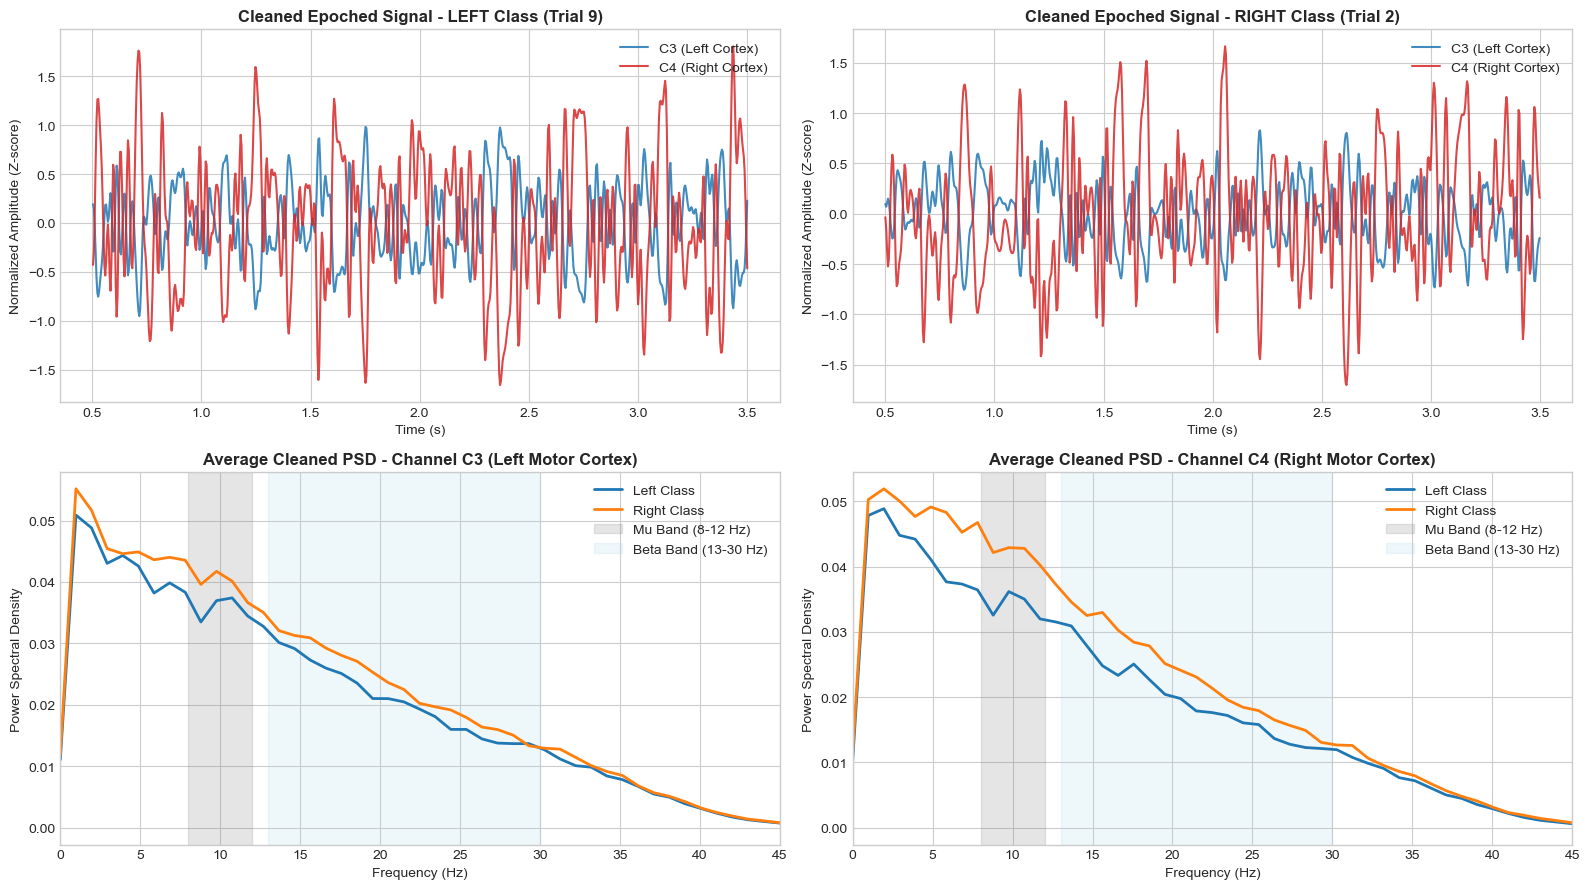

In [22]:
# Configure plotting style for clean visual inspection
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

# Select representative sample trials for LEFT and RIGHT classes
sample_left = df_ready[df_ready["label"] == "Left"]["trial_id"].iloc[0]
sample_right = df_ready[df_ready["label"] == "Right"]["trial_id"].iloc[0]
trial_left = df_ready[df_ready["trial_id"] == sample_left]
trial_right = df_ready[df_ready["trial_id"] == sample_right]



# --- 1. Time-Domain Signal Inspection (Normalized Amplitude) ---
# LEFT Trial - C3 vs C4 Channels
axes[0, 0].plot(trial_left["Time"], trial_left["C3"], label="C3 (Left Cortex)", color="#1f77b4", alpha=0.85)
axes[0, 0].plot(trial_left["Time"], trial_left["C4"], label="C4 (Right Cortex)", color="#d62728", alpha=0.85)
axes[0, 0].set_title(f"Cleaned Epoched Signal - LEFT Class (Trial {sample_left})", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Time (s)")
axes[0, 0].set_ylabel("Normalized Amplitude (Z-score)")
axes[0, 0].legend(loc="upper right")

# RIGHT Trial - C3 vs C4 Channels
axes[0, 1].plot(trial_right["Time"], trial_right["C3"], label="C3 (Left Cortex)", color="#1f77b4", alpha=0.85)
axes[0, 1].plot(trial_right["Time"], trial_right["C4"], label="C4 (Right Cortex)", color="#d62728", alpha=0.85)
axes[0, 1].set_title(f"Cleaned Epoched Signal - RIGHT Class (Trial {sample_right})", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Time (s)")
axes[0, 1].set_ylabel("Normalized Amplitude (Z-score)")
axes[0, 1].legend(loc="upper right")


# --- 2. Spectral Analysis (Welch PSD with Highlighted Frequency Bands) ---
def compute_avg_psd(df, label, channel, fs=250):
    trials = df[df["label"] == label]["trial_id"].unique()
    psds = []
    for t_id in trials:
        sig = df[df["trial_id"] == t_id][channel].values
        freqs, psd = welch(sig, fs=fs, nperseg=min(len(sig), 256))
        psds.append(psd)
    return freqs, np.mean(psds, axis=0)

# Channel C3 (Left Motor Cortex) PSD
f_l_c3, psd_l_c3 = compute_avg_psd(df_ready, "Left", "C3")
f_r_c3, psd_r_c3 = compute_avg_psd(df_ready, "Right", "C3")
axes[1, 0].plot(f_l_c3, psd_l_c3, label="Left Class", color="#1f77b4", linewidth=2)
axes[1, 0].plot(f_r_c3, psd_r_c3, label="Right Class", color="#ff7f0e", linewidth=2)
axes[1, 0].set_xlim(0, 45)
axes[1, 0].set_title("Average Cleaned PSD - Channel C3 (Left Motor Cortex)", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Frequency (Hz)")
axes[1, 0].set_ylabel("Power Spectral Density")
axes[1, 0].axvspan(8, 12, color="gray", alpha=0.2, label="Mu Band (8-12 Hz)")
axes[1, 0].axvspan(13, 30, color="lightblue", alpha=0.2, label="Beta Band (13-30 Hz)")
axes[1, 0].legend()

# Channel C4 (Right Motor Cortex) PSD
f_l_c4, psd_l_c4 = compute_avg_psd(df_ready, "Left", "C4")
f_r_c4, psd_r_c4 = compute_avg_psd(df_ready, "Right", "C4")
axes[1, 1].plot(f_l_c4, psd_l_c4, label="Left Class", color="#1f77b4", linewidth=2)
axes[1, 1].plot(f_r_c4, psd_r_c4, label="Right Class", color="#ff7f0e", linewidth=2)
axes[1, 1].set_xlim(0, 45)
axes[1, 1].set_title("Average Cleaned PSD - Channel C4 (Right Motor Cortex)", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Frequency (Hz)")
axes[1, 1].set_ylabel("Power Spectral Density")
axes[1, 1].axvspan(8, 12, color="gray", alpha=0.2, label="Mu Band (8-12 Hz)")
axes[1, 1].axvspan(13, 30, color="lightblue", alpha=0.2, label="Beta Band (13-30 Hz)")
axes[1, 1].legend()


plt.tight_layout()
plt.show()